# Non-new complex rules across stages — all FOVs


## Imports


In [1]:
import os
import sys
import warnings

from IPython.display import Markdown, display

warnings.filterwarnings("ignore")
sys.path[:0] = [os.path.abspath(".."), os.path.abspath("../..")]

import data_helper as dh
import vis_helper as vh
import complex_stages_helper as stage
import complex_stages_vis as vis


## Parameters


In [2]:
RULE_MAX_ITEMS = 4
KINDS = ["attracts", "avoids"]
MAX_FDR = 0.05
STRENGTH_METRIC = "Lift"

SCORE_COLUMN = "Pathological score"
STAGES = ["Control", "Mild", "Severe"]
ORGANS = ["Colon", "Duodenum"]

USE_CELL_ELIGIBILITY = False
MIN_CELLS_PER_TYPE = 20
MIN_RULE_FOVS = 5
TOP_RULES = 12
DETAIL_RULES = 2

TEX_RULE_EXPORTS = {
    ("attracts", "Colon", "Goblet, Macrophage -> Epithelial, Plasma"): {
        "strength": "complex_nonnew_all_goblet_macrophage_epithelial_plasma_strength.png",
    },
}


## Data loading


In [3]:
df_cells, df_fovs, df_biopsy = dh.load_spatial_data()
df_results = dh.load_results(
    rule_max_items=RULE_MAX_ITEMS,
    kind=None,
    max_fdr=1.0,
    informative_only=False,
)
all_rules = stage.prepare_rules(df_results, df_fovs)


Dropped 21 FOVs: Control_S


Loaded 598093 cells; FOVs: 267, biopsies: 73, patients: 71


Read results_CN_pairwise.csv + results_CN_complex.csv
Loaded 1190114 rules.


Kept 1190114 rules at FDR <= 1.0.


Kept 1172931 rules naming no Unidentified.


Kept 1172931 rules (max_items=4, kind=None).


## Short analysis functions


In [4]:
def strength_label(kind):
    return STRENGTH_METRIC


def scope_label(kind):
    denominator = (
        f"{MIN_CELLS_PER_TYPE}+ cells per rule cell type"
        if USE_CELL_ELIGIBILITY else "all FOVs"
    )
    return " · ".join([
        kind,
        "non-new complex rules",
        f"stage column: {SCORE_COLUMN}",
        f"FDR <= {MAX_FDR}",
        denominator,
        f"at least {MIN_RULE_FOVS} rule FOVs in one stage",
    ])


## Results


In [5]:
vis.clear_exports([
    filename
    for rule_exports in TEX_RULE_EXPORTS.values()
    for filename in rule_exports.values()
])

def show_kind(kind):
    display(Markdown(f"## {kind.title()}"))
    kind_rules = all_rules[all_rules["Kind"] == kind].copy()
    complex_rules = stage.select_complex_rules(
        kind_rules,
        max_fdr=MAX_FDR,
        new_only=False,
        min_strength=1.0,
        metric=STRENGTH_METRIC,
    )
    eligibility = stage.rule_eligibility(
        complex_rules, df_cells, MIN_CELLS_PER_TYPE
    )

    for organ in ORGANS:
        display(Markdown(f"### {organ}"))
        prevalence = stage.stage_prevalence(
            complex_rules,
            kind_rules,
            eligibility,
            df_fovs,
            organ,
            STAGES,
            SCORE_COLUMN,
            MAX_FDR,
            USE_CELL_ELIGIBILITY,
        )
        top, ranked_names = stage.rank_rules(
            prevalence, STAGES, MIN_RULE_FOVS, TOP_RULES
        )
        display(stage.result_table(top, new_only=False))
        vis.plot_prevalence_overview(
            top, STAGES, organ=organ, params=scope_label(kind)
        )

        chosen = stage.detail_rules(
            complex_rules, ranked_names, DETAIL_RULES, new_only=False
        )
        report_rules = [
            rule
            for export_kind, export_organ, rule in TEX_RULE_EXPORTS
            if export_kind == kind and export_organ == organ and rule in ranked_names
        ]
        chosen = list(dict.fromkeys(chosen + report_rules))
        for name in chosen:
            export = TEX_RULE_EXPORTS.get((kind, organ, name), {})
            rule_prevalence = top[top["name"].astype(str) == name].copy()
            strengths = stage.patient_strengths(
                name,
                complex_rules,
                kind_rules,
                eligibility,
                df_fovs,
                organ,
                STAGES,
                SCORE_COLUMN,
                STRENGTH_METRIC,
                USE_CELL_ELIGIBILITY,
            )
            vis.plot_prevalence_and_strength(
                rule_prevalence,
                strengths,
                STAGES,
                metric=strength_label(kind),
                organ=organ,
                params=scope_label(kind),
                new_only=False,
                save=export.get("strength"),
            )
            examples = stage.fov_examples(
                name,
                complex_rules,
                kind_rules,
                eligibility,
                df_fovs,
                organ,
                STAGES,
                SCORE_COLUMN,
                STRENGTH_METRIC,
                USE_CELL_ELIGIBILITY,
                new_only=False,
            )
            vh.plot_stage_rule_fovs(
                examples,
                STAGES,
                df_cells,
                df_fovs,
                organ=organ,
                subtitle="Complex rule and strongest simpler rule",
                params=scope_label(kind),
                cell_size=11,
                save=export.get("fovs"),
            )


## Attractions


## Attracts

### Colon

,name,stage,complex prevalence,simpler prevalence
738,"Goblet, Macrophage -> Epithelial, Plasma",Control,12 / 25 (48%),23 / 25 (92%)
739,"Goblet, Macrophage -> Epithelial, Plasma",Mild,1 / 40 (2%),20 / 40 (50%)
740,"Goblet, Macrophage -> Epithelial, Plasma",Severe,3 / 32 (9%),19 / 32 (59%)
726,"Fibroblast, Goblet -> Epithelial, Plasma",Control,10 / 25 (40%),22 / 25 (88%)
727,"Fibroblast, Goblet -> Epithelial, Plasma",Mild,1 / 40 (2%),20 / 40 (50%)
728,"Fibroblast, Goblet -> Epithelial, Plasma",Severe,1 / 32 (3%),17 / 32 (53%)
771,"CD4T, Goblet -> Epithelial, Macrophage",Control,9 / 25 (36%),20 / 25 (80%)
772,"CD4T, Goblet -> Epithelial, Macrophage",Mild,1 / 40 (2%),22 / 40 (55%)
773,"CD4T, Goblet -> Epithelial, Macrophage",Severe,1 / 32 (3%),18 / 32 (56%)
2001,"Epithelial, SMV -> Goblet, Plasma",Control,8 / 25 (32%),24 / 25 (96%)


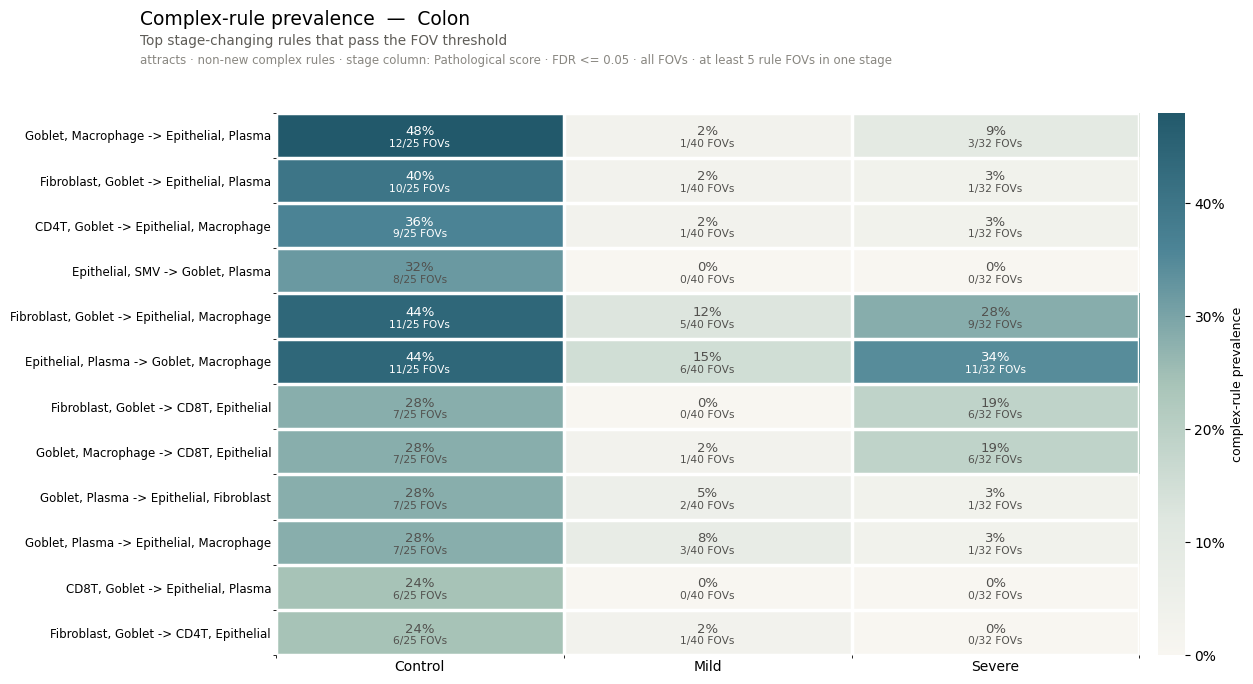

saved C:\Users\Owner\Documents\worktrees\script-rule-mining-wt-2\result_summary\complex_rules\summary_downloads\complex_nonnew_all_goblet_macrophage_epithelial_plasma_strength.png


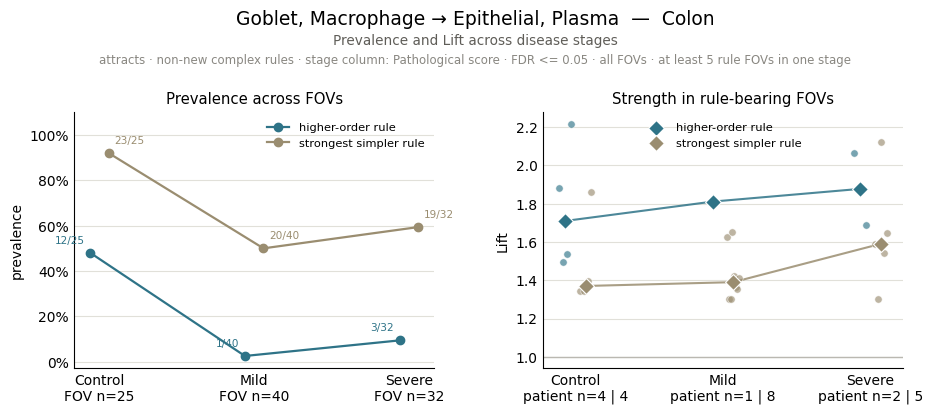

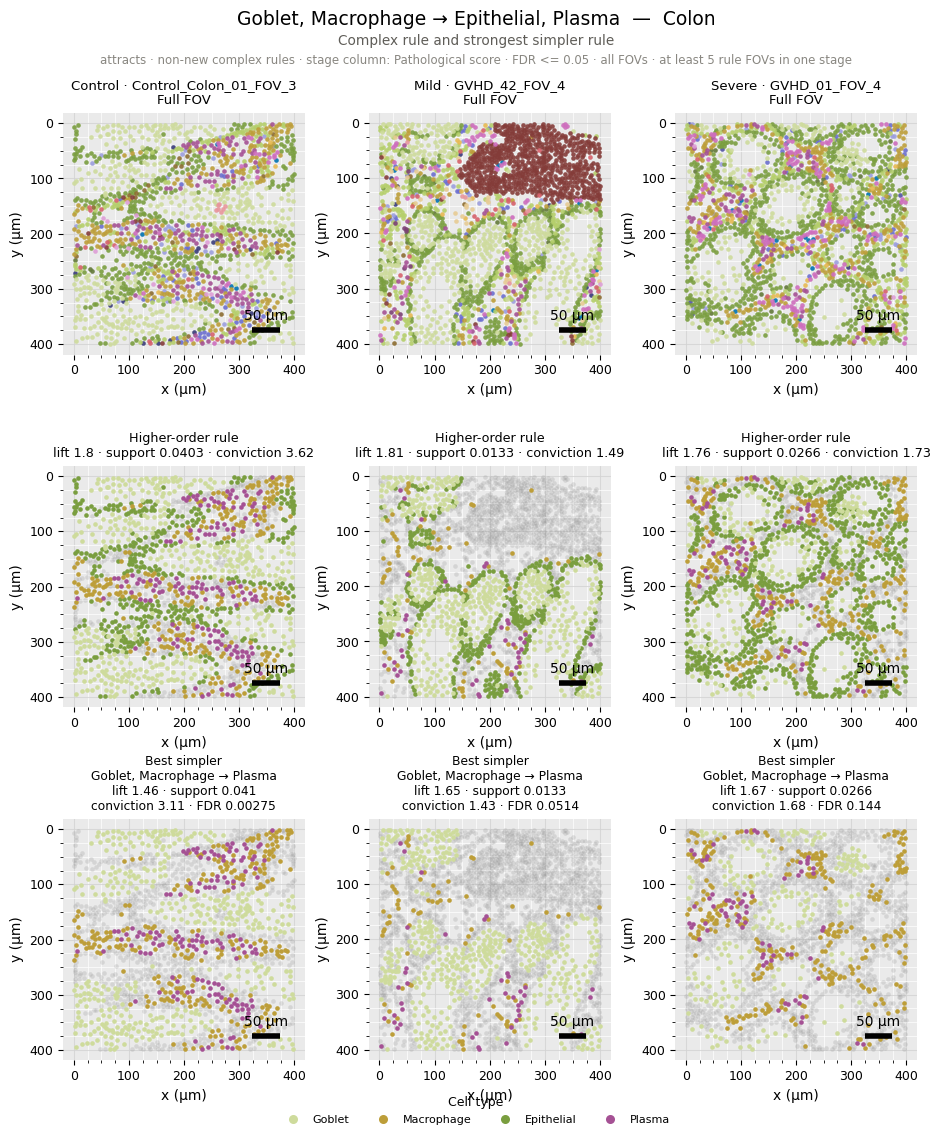

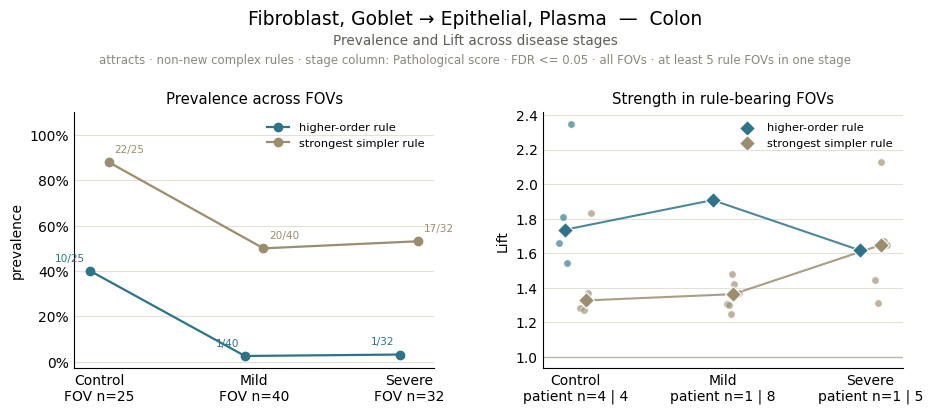

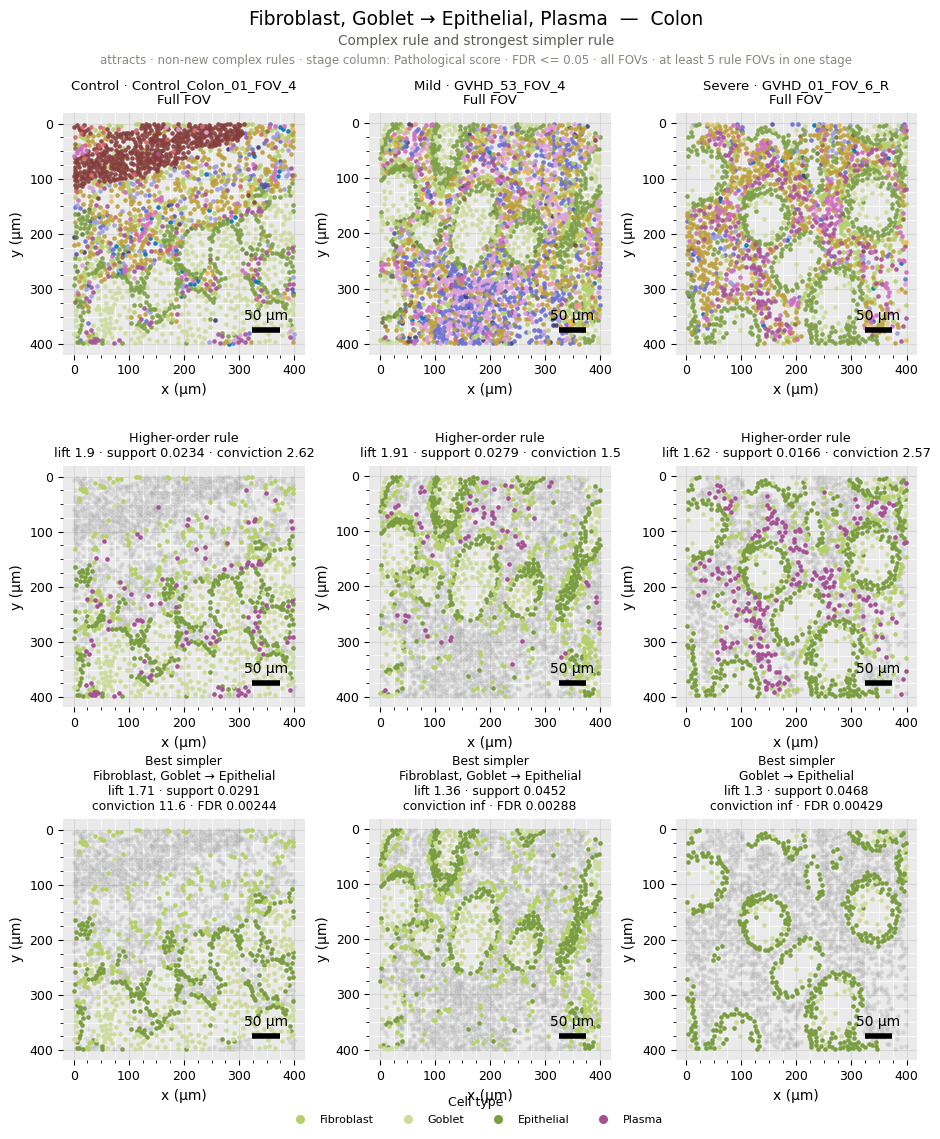

### Duodenum

,name,stage,complex prevalence,simpler prevalence
513,"CD4T, Goblet -> Epithelial, Plasma",Control,9 / 31 (29%),25 / 31 (81%)
514,"CD4T, Goblet -> Epithelial, Plasma",Mild,6 / 103 (6%),68 / 103 (66%)
515,"CD4T, Goblet -> Epithelial, Plasma",Severe,0 / 36 (0%),7 / 36 (19%)
738,"Goblet, Macrophage -> Epithelial, Plasma",Control,9 / 31 (29%),25 / 31 (81%)
739,"Goblet, Macrophage -> Epithelial, Plasma",Mild,15 / 103 (15%),71 / 103 (69%)
740,"Goblet, Macrophage -> Epithelial, Plasma",Severe,1 / 36 (3%),10 / 36 (28%)
4431,"Epithelial, SMV -> Fibroblast, Goblet",Control,0 / 31 (0%),29 / 31 (94%)
4432,"Epithelial, SMV -> Fibroblast, Goblet",Mild,25 / 103 (24%),86 / 103 (83%)
4433,"Epithelial, SMV -> Fibroblast, Goblet",Severe,2 / 36 (6%),15 / 36 (42%)
9876,"Fibroblast, Paneth -> Epithelial, SMV",Control,0 / 31 (0%),16 / 31 (52%)


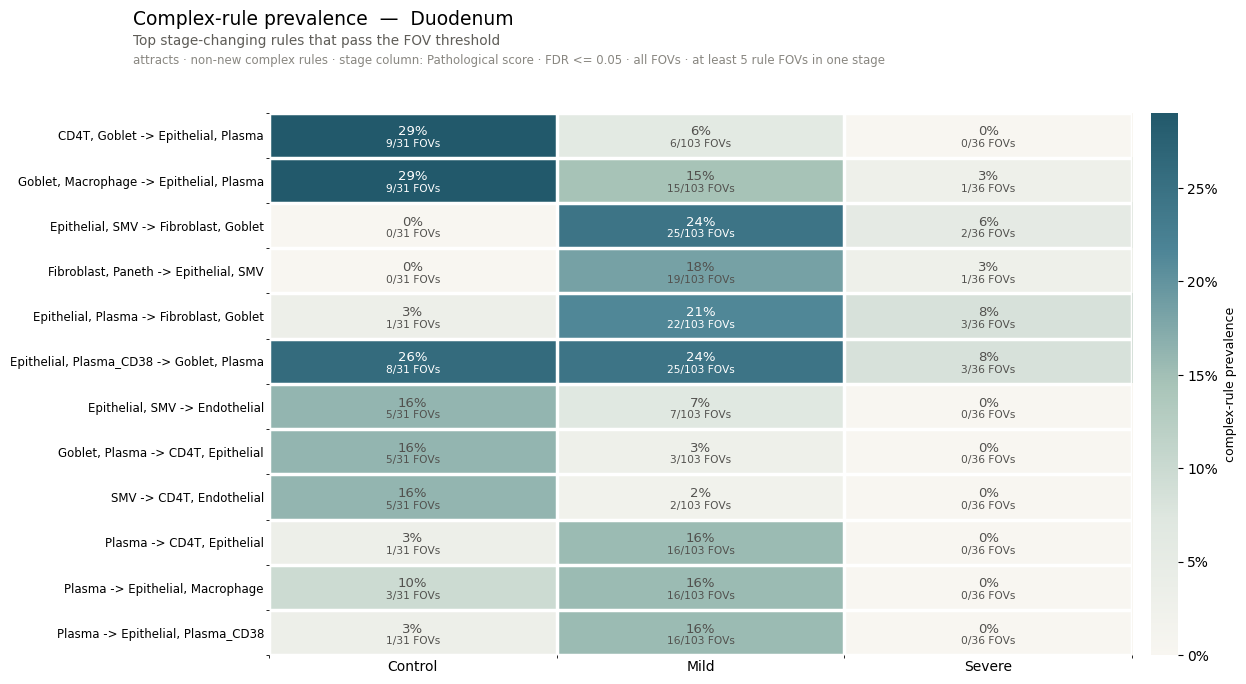

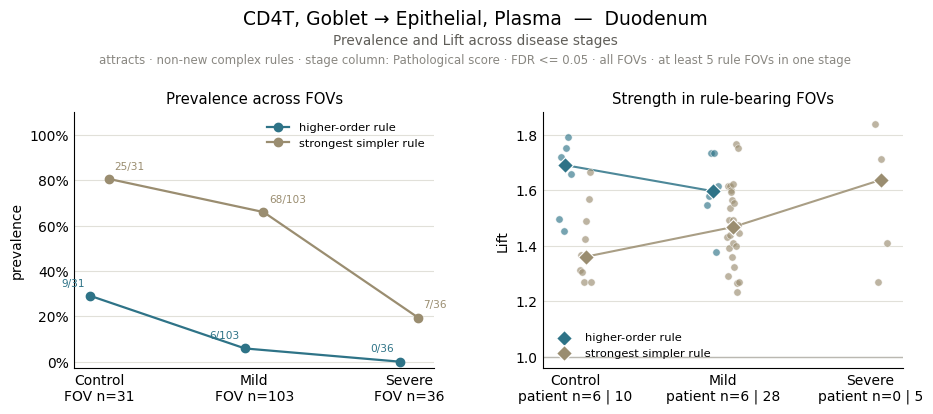

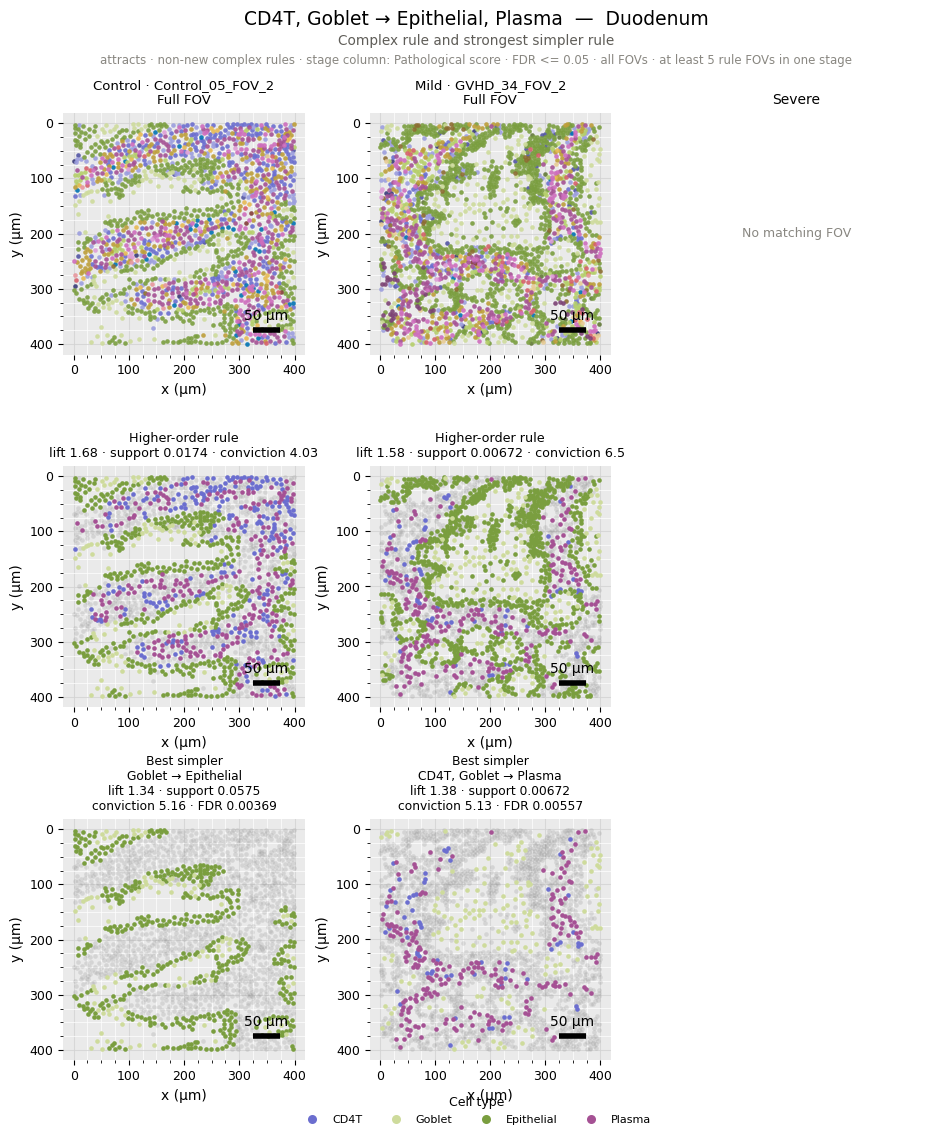

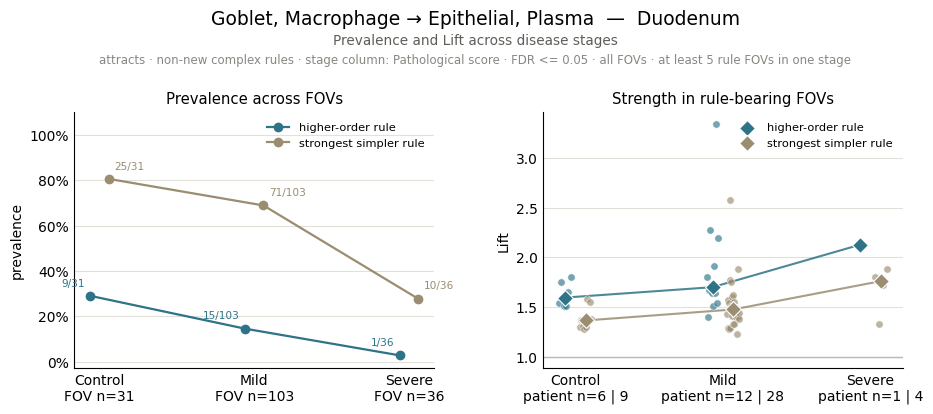

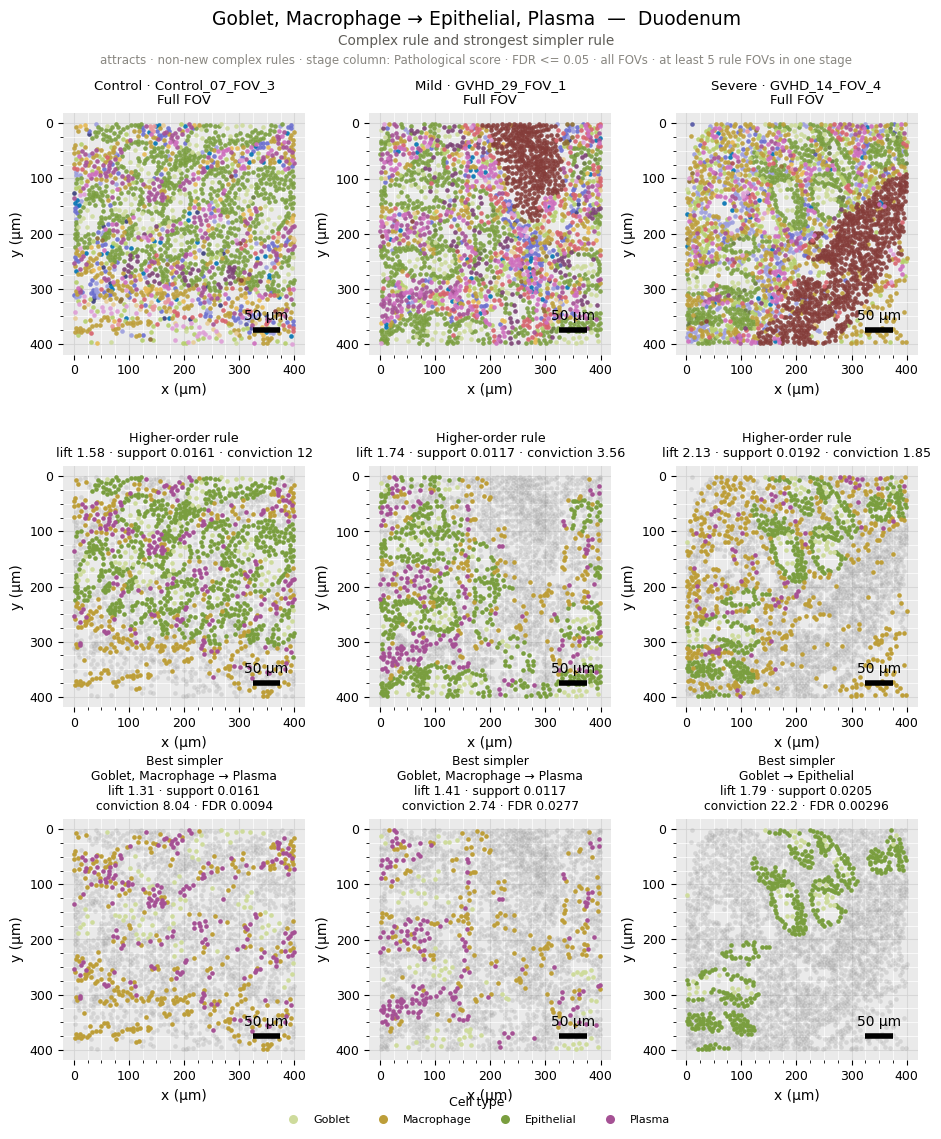

In [6]:
show_kind("attracts")


## Avoidances (negative spatial rules)


## Avoids

### Colon

,name,stage,complex prevalence,simpler prevalence
549,"Goblet -> CD8T, Plasma",Control,23 / 25 (92%),25 / 25 (100%)
550,"Goblet -> CD8T, Plasma",Mild,5 / 40 (12%),34 / 40 (85%)
551,"Goblet -> CD8T, Plasma",Severe,4 / 32 (12%),25 / 32 (78%)
762,"Goblet -> CD4T, Plasma",Control,22 / 25 (88%),25 / 25 (100%)
763,"Goblet -> CD4T, Plasma",Mild,7 / 40 (18%),31 / 40 (78%)
764,"Goblet -> CD4T, Plasma",Severe,3 / 32 (9%),18 / 32 (56%)
315,"Goblet -> CD8T, Fibroblast, Plasma",Control,17 / 25 (68%),25 / 25 (100%)
316,"Goblet -> CD8T, Fibroblast, Plasma",Mild,0 / 40 (0%),39 / 40 (98%)
317,"Goblet -> CD8T, Fibroblast, Plasma",Severe,1 / 32 (3%),25 / 32 (78%)
309,"Goblet -> CD4T, CD8T",Control,24 / 25 (96%),25 / 25 (100%)


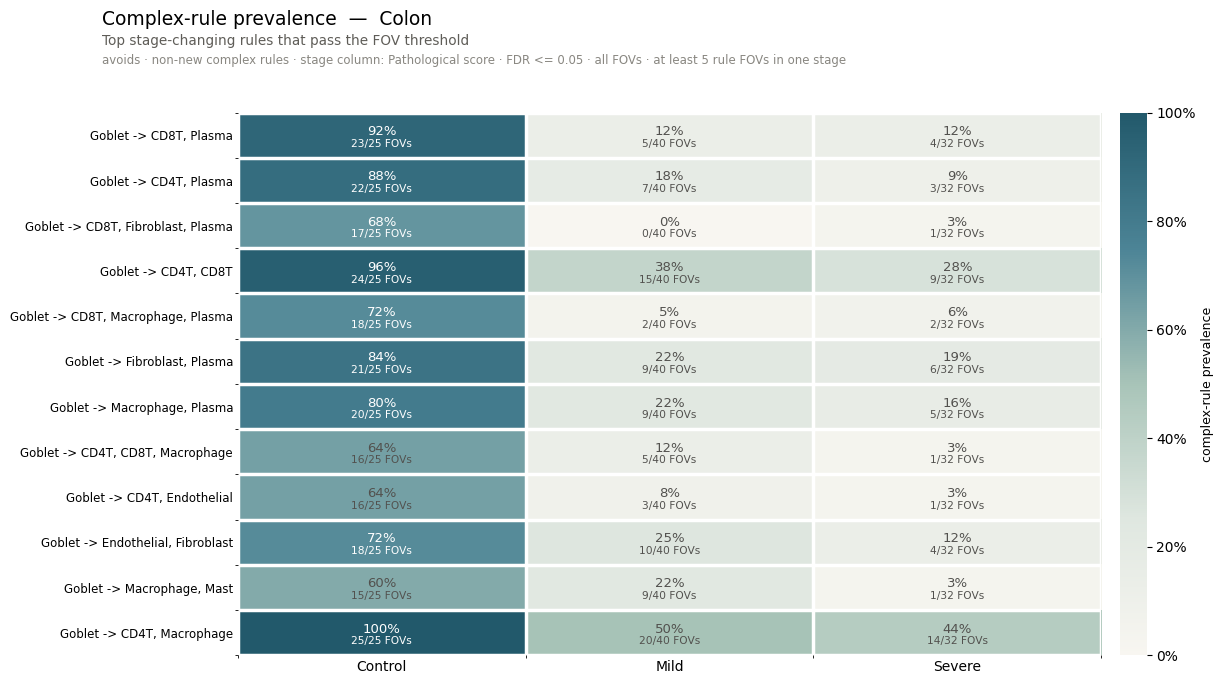

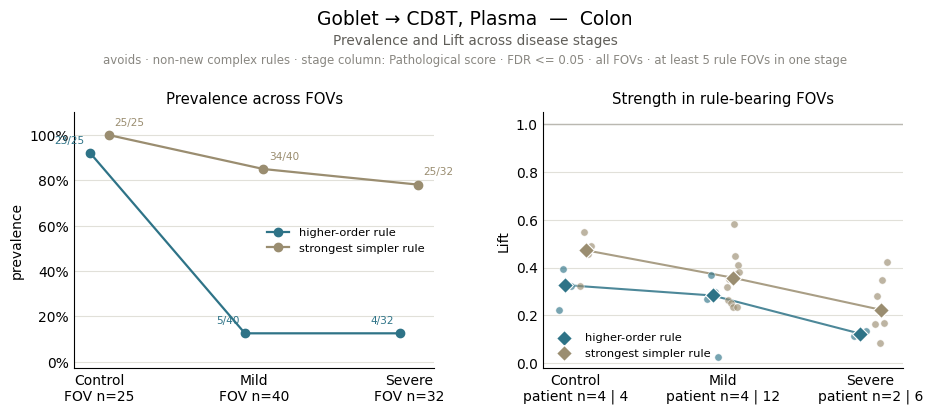

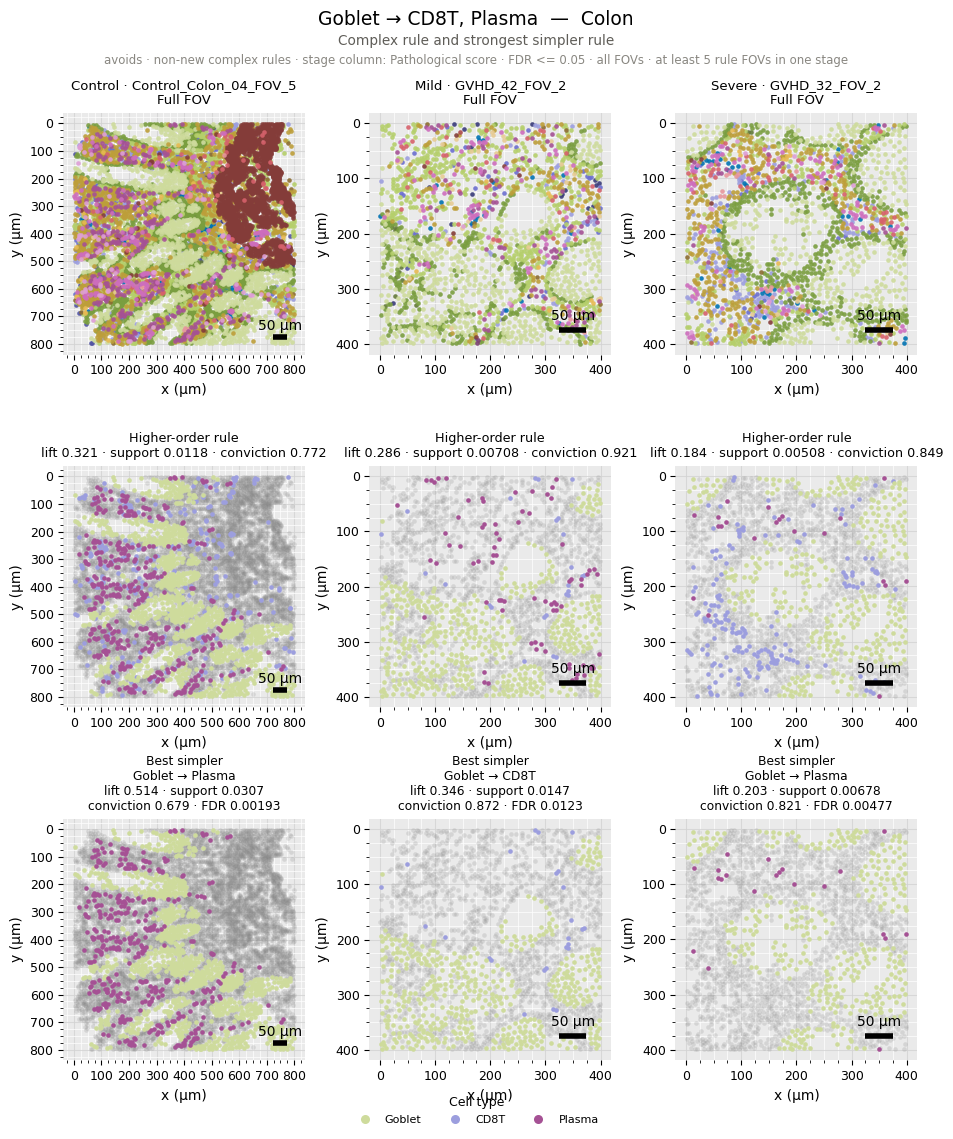

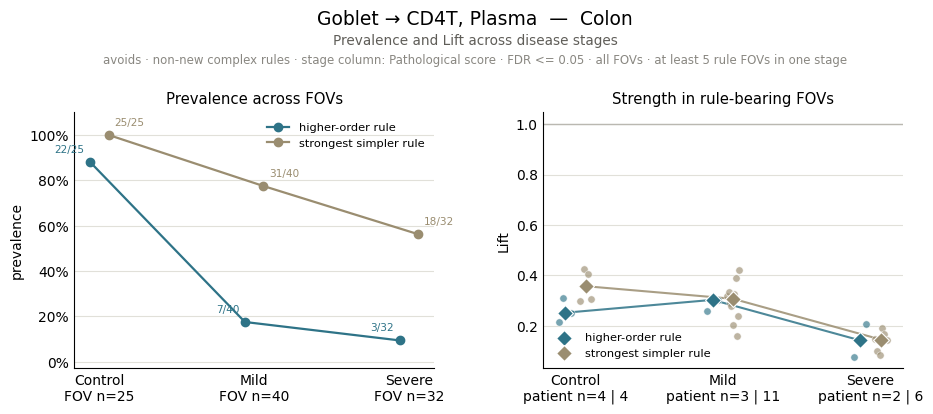

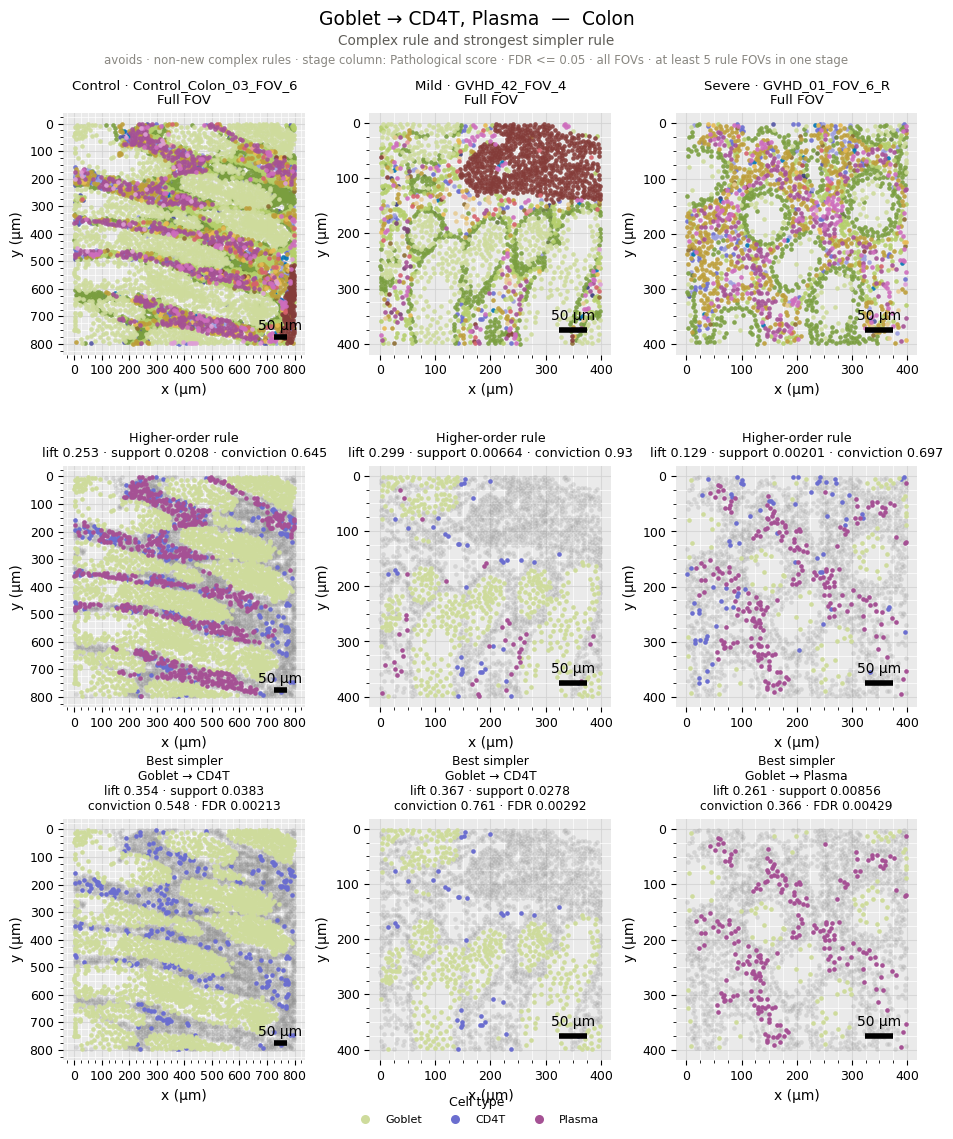

### Duodenum

,name,stage,complex prevalence,simpler prevalence
39,"Goblet -> CD4T, Macrophage",Control,20 / 31 (65%),29 / 31 (94%)
40,"Goblet -> CD4T, Macrophage",Mild,52 / 103 (50%),86 / 103 (83%)
41,"Goblet -> CD4T, Macrophage",Severe,4 / 36 (11%),12 / 36 (33%)
537,"Goblet -> Fibroblast, Macrophage",Control,22 / 31 (71%),29 / 31 (94%)
538,"Goblet -> Fibroblast, Macrophage",Mild,73 / 103 (71%),88 / 103 (85%)
539,"Goblet -> Fibroblast, Macrophage",Severe,8 / 36 (22%),12 / 36 (33%)
2751,"Goblet -> Fibroblast, Neuron",Control,1 / 31 (3%),26 / 31 (84%)
2752,"Goblet -> Fibroblast, Neuron",Mild,47 / 103 (46%),84 / 103 (82%)
2753,"Goblet -> Fibroblast, Neuron",Severe,4 / 36 (11%),11 / 36 (31%)
324,"Goblet -> Fibroblast, SMV",Control,5 / 31 (16%),27 / 31 (87%)


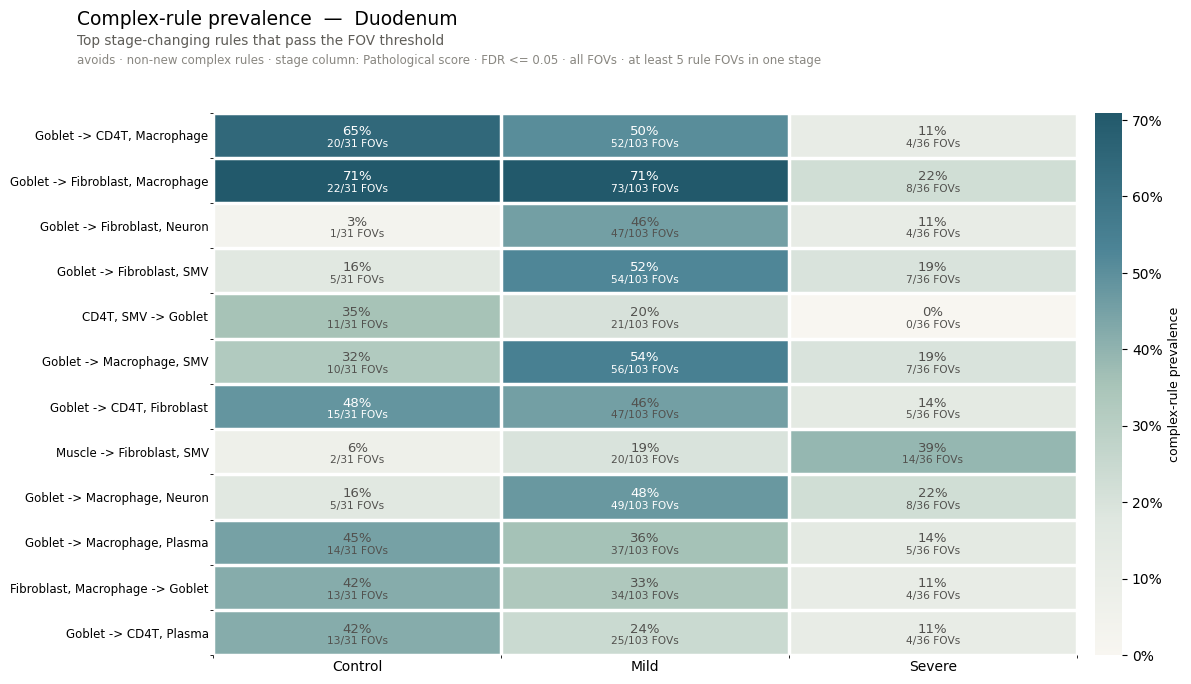

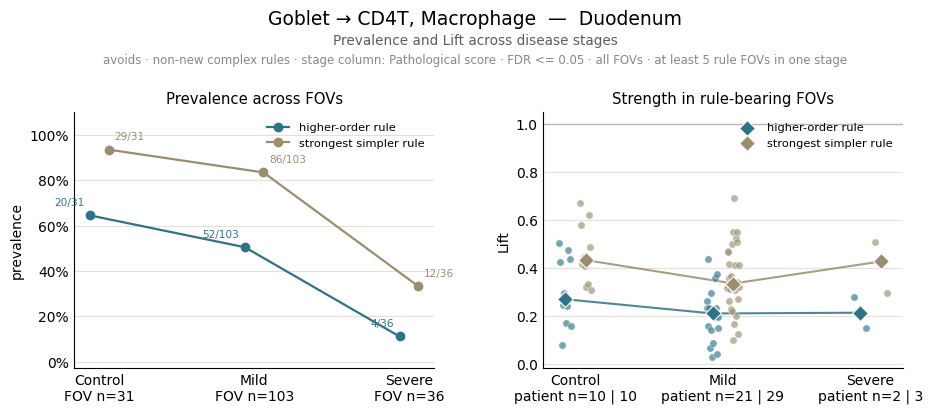

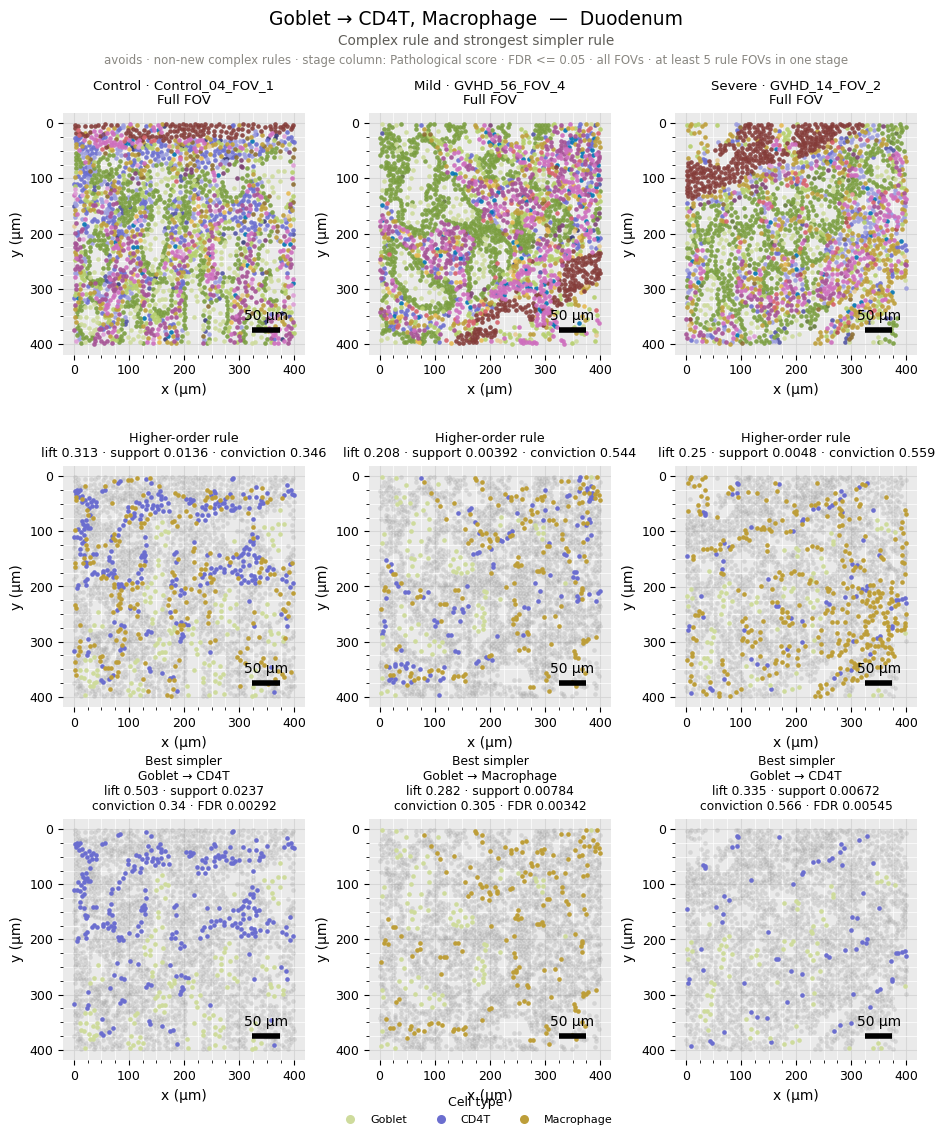

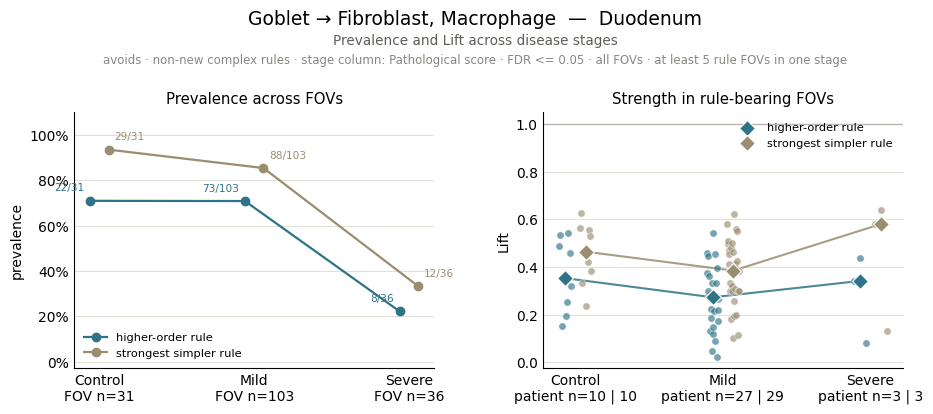

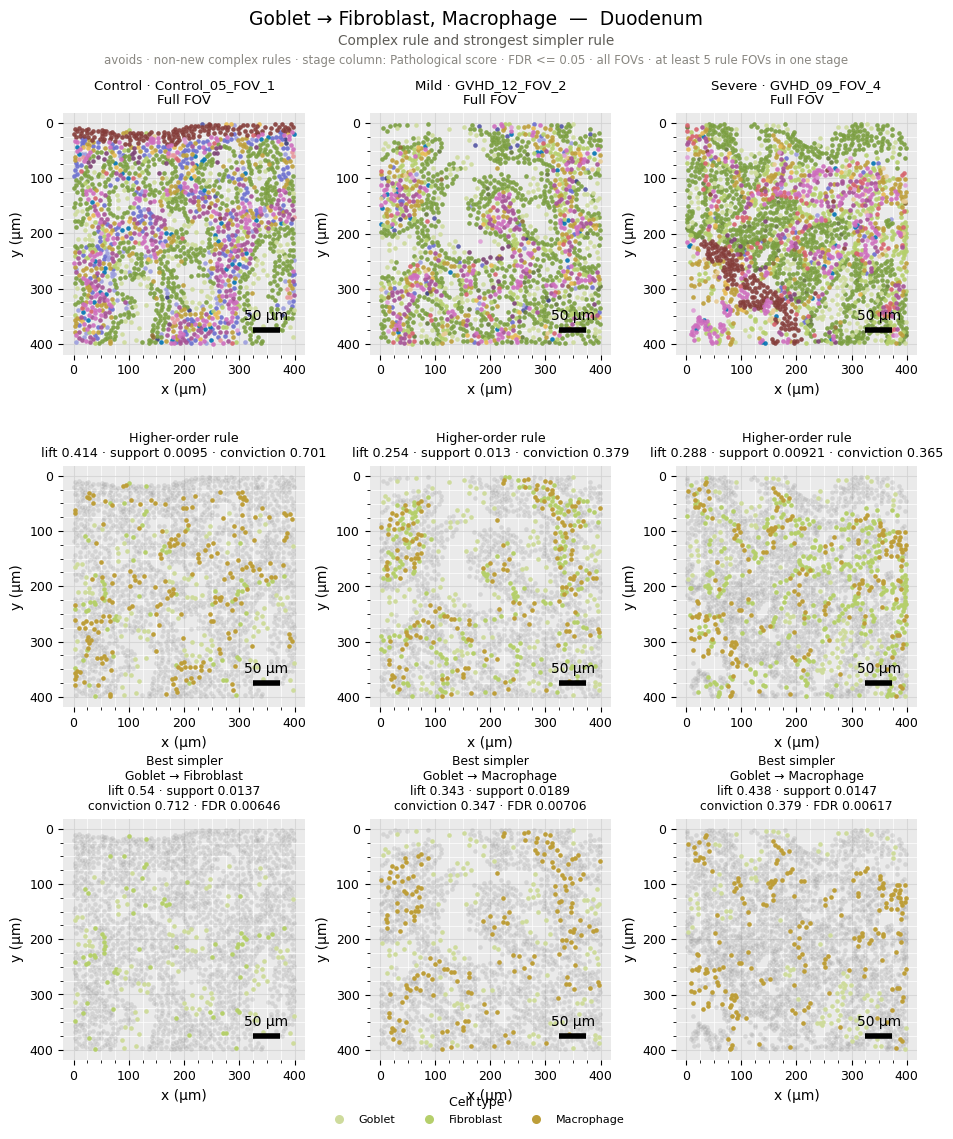

In [7]:
show_kind("avoids")
